In [ ]:
# =====================================================================================
# ENGINEERED-TMS CELL 1: S_4 machinery + group-structured non-negative features + gates.
# Features = group-translated indicator patterns (non-negative -> ReLU-TMS compatible).
# Planted irrep spectrum = the indicator's irrep energies, computed EXACTLY.
# =====================================================================================
import numpy as np, torch, torch.nn as nn
from itertools import permutations
from collections import defaultdict
PASS = lambda b: "✓" if b else "✗✗✗ FAIL"

# --- S_4 (validated construction) ---
elements = list(permutations(range(4))); n = len(elements)
idx = {g:i for i,g in enumerate(elements)}
compose = lambda s,t: tuple(s[t[x]] for x in range(4))
cayley = np.array([[idx[compose(gi,gj)] for gj in elements] for gi in elements])
def cyc(p):
    seen=[False]*4; cs=[]
    for s in range(4):
        if not seen[s]:
            Lc=0;x=s
            while not seen[x]: seen[x]=True; x=p[x]; Lc+=1
            cs.append(Lc)
    return tuple(sorted(cs,reverse=True))
classes=defaultdict(list)
for i,g in enumerate(elements): classes[cyc(g)].append(i)
class_order=[(1,1,1,1),(2,1,1),(2,2),(3,1),(4,)]
elem_class=np.zeros(n,dtype=int)
for ci,ct in enumerate(class_order):
    for x in classes[ct]: elem_class[x]=ci
char_table=np.array([[1,1,1,1,1],[1,-1,1,1,-1],[2,0,2,-1,0],
                     [3,1,-1,0,-1],[3,-1,-1,0,1]],dtype=float)
dims=char_table[:,0].astype(int); G=float(n)
L=np.zeros((n,n,n))
for g in range(n):
    for j in range(n): L[g,cayley[g,j],j]=1.0
Ps=[(dims[r]/G)*sum(char_table[r,elem_class[g]]*L[g] for g in range(n)) for r in range(5)]
names=["triv","sign","2d","3d_a","3d_b"]

# GATES (machinery)
comp=np.linalg.norm(sum(Ps)-np.eye(n))
print(f"GATE projectors (completeness={comp:.0e}, idempotent): "
      f"{PASS(comp<1e-9 and all(np.allclose(P@P,P,atol=1e-9) for P in Ps))}")
rng=np.random.default_rng(1)
def irrep_frac_rows(W):   # W: (n x m), rows = features = group elements
    ev=np.array([np.sum((P@W)**2) for P in Ps]); return ev/ev.sum()
print(f"GATE isolation: {PASS(all(irrep_frac_rows(Ps[r]@rng.standard_normal((n,8)))[r]>0.99 for r in range(5)))}")

# --- data: translated indicator patterns ---
def make_group_tms_data(S, seed, N=100000, amp_lo=0.5, amp_hi=1.5):
    """Each sample: pick group element g, activate features g.S with one positive amplitude."""
    r = np.random.default_rng(seed)
    ind = np.zeros(n); ind[list(S)] = 1.0
    planted = np.array([np.sum((Ps[k]@ind)**2) for k in range(5)])   # EXACT ground truth
    T = np.stack([L[g]@ind for g in range(n)])
    gs = r.integers(0,n,N); amps = r.uniform(amp_lo, amp_hi, N)
    X = (amps[:,None]*T[gs]).astype(np.float32)
    # verification gates on the data itself
    Sig = X.T@X/N; Ea2 = (amps**2).mean()
    tr = np.array([np.trace(Ps[k]@Sig) for k in range(5)])/Ea2
    g_pos = bool((X>=0).all())
    g_spec = np.allclose(tr, planted, atol=0.03)
    print(f"  data gates: non-negative {PASS(g_pos)} | planted spectrum recovered {PASS(g_spec)}")
    print(f"  planted irrep variances: {np.round(planted,3).tolist()}")
    assert g_pos and g_spec
    return X, planted

# ARM A data: dominant 3d_b planted (validation arm)
print("\nARM A data (S={0,3,7,10}: 3d_b dominant, 1.5 vs 1.0):")
X_A, planted_A = make_group_tms_data([0,3,7,10], seed=0)
# ARM B data: two 3d irreps planted EXACTLY EQUAL (the selection question)
print("ARM B data (S={0,1,8}: 3d_a = 3d_b = 1.125 exactly):")
X_B, planted_B = make_group_tms_data([0,1,8], seed=1)

GATE projectors (completeness=0e+00, idempotent): ✓
GATE isolation: ✓

ARM A data (S={0,3,7,10}: 3d_b dominant, 1.5 vs 1.0):
  data gates: non-negative ✓ | planted spectrum recovered ✓
  planted irrep variances: [0.667, 0.167, 0.667, 1.0, 1.5]
ARM B data (S={0,1,8}: 3d_a = 3d_b = 1.125 exactly):
  data gates: non-negative ✓ | planted spectrum recovered ✓
  planted irrep variances: [0.375, 0.042, 0.333, 1.125, 1.125]


In [ ]:
# =====================================================================================
# ENGINEERED-TMS CELL 2: train TMS under bottleneck sweep, read which irreps are kept.
# ARM A (validation): dominant irrep planted -> bottlenecked net should keep it.
# ARM B (the question): equal 3d irreps, m too small for both -> SPLIT or COLLAPSE?
#   COLLAPSE (PR~1, one 3d) -> selection phenomenon extends to superposition. POSITIVE.
#   SPLIT   (PR~2, both)    -> selection is computation-specific. Honest negative, still a result.
# CONTROL: unstructured data -> fractions at null (artifact check).
# =====================================================================================
class TMS(nn.Module):
    def __init__(s, n=24, m=6):
        super().__init__()
        s.W = nn.Parameter(torch.randn(m,n)*0.1)
        s.b = nn.Parameter(torch.zeros(n))
    def forward(s,x): return torch.relu(x @ s.W.T @ s.W + s.b)

def train_tms(X, m, seed, steps=15000, lr=3e-3, wd=0.01):
    torch.manual_seed(seed)
    Xt = torch.tensor(X); model = TMS(n,m)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    for s in range(steps):
        xb = Xt[torch.randint(0,len(Xt),(2048,))]
        loss = ((model(xb)-xb)**2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return model.W.detach().numpy().T, float(loss.item())   # (n x m), rows group-indexed

null_frac = dims.astype(float)**2/G
print("null fractions:", np.round(null_frac,3).tolist())

print("\n" + "="*96)
print("ARM A (validation): 3d_b planted dominant. Does the bottlenecked net keep the dominant irrep?")
print("="*96)
for m in [3, 6, 9]:
    W,loss = train_tms(X_A, m, seed=0)
    f = irrep_frac_rows(W)
    print(f"  m={m}: loss={loss:.4f}  fracs={np.round(f,3).tolist()}  dom={names[int(np.argmax(f))]}")

print("\n" + "="*96)
print("ARM B (the question): 3d_a = 3d_b exactly. m=4 cannot hold both (needs 6). COLLAPSE or SPLIT?")
print("="*96)
print(f"{'m':>3}{'seed':>6}{'loss':>9}{'PR':>7}{'3d_a':>8}{'3d_b':>8}   verdict")
for m in [3, 4, 5]:
    for sd in range(6):
        W,loss = train_tms(X_B, m, seed=sd)
        f = irrep_frac_rows(W); pr = 1.0/np.sum(f**2)
        verdict = ("COLLAPSE onto one" if max(f[3],f[4])>0.75 and min(f[3],f[4])<0.15
                   else "split across both" if min(f[3],f[4])>0.25 else "mixed")
        print(f"{m:>3}{sd:>6}{loss:>9.4f}{pr:>7.2f}{f[3]:>8.3f}{f[4]:>8.3f}   {verdict}")

print("\n" + "="*96)
print("CONTROL: unstructured sparse data (no group structure) -> W fractions should sit at null")
print("="*96)
rC = np.random.default_rng(9)
X_C = (rC.uniform(0.5,1.5,(100000,n)) * (rC.random((100000,n))<0.125)).astype(np.float32)
W,loss = train_tms(X_C, 4, seed=0)
f = irrep_frac_rows(W)
print(f"  fracs={np.round(f,3).tolist()} vs null={np.round(null_frac,3).tolist()}"
      f"  max dev={np.abs(f-null_frac).max():.3f}  {PASS(np.abs(f-null_frac).max()<0.12)}")

null fractions: [0.042, 0.042, 0.167, 0.375, 0.375]

ARM A (validation): 3d_b planted dominant. Does the bottlenecked net keep the dominant irrep?
  m=3: loss=0.0717  fracs=[0.0, 0.03, 0.313, 0.132, 0.524]  dom=3d_b
  m=6: loss=0.0061  fracs=[0.0, 0.017, 0.146, 0.31, 0.528]  dom=3d_b
  m=9: loss=0.0005  fracs=[0.0, 0.024, 0.113, 0.32, 0.542]  dom=3d_b

ARM B (the question): 3d_a = 3d_b exactly. m=4 cannot hold both (needs 6). COLLAPSE or SPLIT?
  m  seed     loss     PR    3d_a    3d_b   verdict
  3     0   0.0209   1.00   0.000   1.000   COLLAPSE onto one
  3     1   0.0211   1.00   0.000   1.000   COLLAPSE onto one
  3     2   0.0356   1.85   0.327   0.658   split across both
  3     3   0.0212   1.00   0.000   1.000   COLLAPSE onto one
  3     4   0.0358   1.85   0.327   0.659   split across both
  3     5   0.0357   1.85   0.339   0.653   split across both
  4     0   0.0109   1.62   0.052   0.762   COLLAPSE onto one
  4     1   0.0113   1.62   0.052   0.762   COLLAPSE onto one
  4

In [ ]:
# CONTROL: does the collapse target track the construction, or is it always 3d_b?
# Find several DIFFERENT subsets with 3d_a ≈ 3d_b (equal second moments), train at m=4,
# and record which irrep wins per construction.
from itertools import combinations
cands = []
for k in [3, 4, 5]:
    for S2 in combinations(range(1, n), k-1):
        Sfull = (0,) + S2
        v = np.zeros(n); v[list(Sfull)] = 1.0
        e = np.array([np.sum((Ps[r]@v)**2) for r in range(5)])
        if e[3] > 0.3 and e[4] > 0.3 and abs(e[3]-e[4]) < 0.02 and e[2] < 0.5*min(e[3], e[4]):
            cands.append((Sfull, e))
    if len(cands) >= 5: break
print(f"found {len(cands)} balanced constructions\n")
print(f"{'subset':<22}{'3d_a':>7}{'3d_b':>7}   winners across 4 seeds (m=4)")
for Sfull, e in cands[:5]:
    X_c, _ = make_group_tms_data(list(Sfull), seed=hash(Sfull) % 10000)
    wins = []
    for sd in range(4):
        W, _ = train_tms(X_c, 4, seed=sd)
        f = irrep_frac_rows(W)
        wins.append("a" if f[3] > f[4] else "b")
    print(f"{str(Sfull):<22}{e[3]:>7.3f}{e[4]:>7.3f}   {' '.join(wins)}")
print("\nREAD: winners vary by construction -> choice is data-determined (collapse finding stands,")
print("      'spontaneous choice' claim needs rewording). Always 3d_b -> investigate before claiming.")

found 88 balanced constructions

subset                   3d_a   3d_b   winners across 4 seeds (m=4)
  data gates: non-negative ✓ | planted spectrum recovered ✓
  planted irrep variances: [0.375, 0.042, 0.333, 1.125, 1.125]
(0, 1, 8)               1.125  1.125   b b b b
  data gates: non-negative ✓ | planted spectrum recovered ✓
  planted irrep variances: [0.375, 0.042, 0.333, 1.125, 1.125]
(0, 1, 9)               1.125  1.125   b b b b
  data gates: non-negative ✓ | planted spectrum recovered ✓
  planted irrep variances: [0.375, 0.042, 0.333, 1.125, 1.125]
(0, 1, 10)              1.125  1.125   b b b b
  data gates: non-negative ✓ | planted spectrum recovered ✓
  planted irrep variances: [0.375, 0.042, 0.333, 1.125, 1.125]
(0, 1, 11)              1.125  1.125   b b b b
  data gates: non-negative ✓ | planted spectrum recovered ✓
  planted irrep variances: [0.375, 0.042, 0.333, 1.125, 1.125]
(0, 1, 12)              1.125  1.125   b b b b

READ: winners vary by construction -> choice is 

In [ ]:
# =====================================================================================
# ENGINEERED-TMS CELL 3: registered-prediction test + spontaneity test, full scale.
# Assumes Cell 1 (machinery, make_group_tms_data, irrep_frac_rows) and Cell 2 (TMS, train_tms)
# are in memory.
# PRE-REGISTERED CLAIMS BEING TESTED:
#  P1: a positivity-sensitive statistic (relu-energy of each 3d component) PREDICTS which
#      irrep wins under collapse. Test: compute stat -> predict -> train -> score accuracy.
#  P2: in moment-SYMMETRIC families, the winner varies across seeds (spontaneous selection).
# =====================================================================================
from itertools import combinations

# --- collect one representative per distinct spectrum family (balanced 3d's) ---
fam = {}
for k in [3,4,5,6]:
    for S2 in combinations(range(1,n), k-1):
        S=(0,)+S2
        v=np.zeros(n); v[list(S)]=1.0
        e=np.array([np.sum((Ps[r]@v)**2) for r in range(5)])
        if abs(e[3]-e[4])<0.02 and min(e[3],e[4])>0.25:
            fam.setdefault(tuple(np.round(e,3)), S)
families = list(fam.values())
print(f"{len(families)} distinct balanced families")

# --- moment statistic and prediction per family ---
def moment_stat(S, N=30000, seed=0):
    r=np.random.default_rng(seed)
    v=np.zeros(n); v[list(S)]=1.0
    T=np.stack([L[g]@v for g in range(n)])
    X=(r.uniform(0.5,1.5,N)[:,None]*T[r.integers(0,n,N)])
    r3=np.mean(np.maximum(X@Ps[3].T,0)**2); r4=np.mean(np.maximum(X@Ps[4].T,0)**2)
    return r3, r4

print("\n" + "="*96)
print("P1: REGISTERED PREDICTIONS — does the moment statistic predict the winner?")
print("="*96)
print(f"{'family':<24}{'stat_a':>8}{'stat_b':>8}{'predict':>9}   winners (4 seeds, m=4)   correct?")
correct, total, sym_families = 0, 0, []
for S in families[:12]:                              # 12 families x 4 seeds = 48 trainings
    ra, rb = moment_stat(S)
    rel = (ra-rb)/max(ra,rb)
    if abs(rel) < 0.02:                              # symmetric -> route to P2
        sym_families.append(S); continue
    pred = "a" if ra>rb else "b"
    X,_ = make_group_tms_data(list(S), seed=hash(S)%9999)
    wins=[]
    for sd in range(4):
        W,_ = train_tms(X, 4, seed=sd)
        f = irrep_frac_rows(W)
        wins.append("a" if f[3]>f[4] else "b")
    hits = sum(w==pred for w in wins); correct+=hits; total+=4
    print(f"{str(S):<24}{ra:>8.4f}{rb:>8.4f}{pred:>9}   {' '.join(wins):<24} {hits}/4")
print(f"\nP1 prediction accuracy: {correct}/{total} = {correct/max(total,1)*100:.0f}%"
      f"  (chance=50%; >80% = statistic genuinely predicts the winner)")

print("\n" + "="*96)
print("P2: SPONTANEITY in moment-symmetric families — does the winner vary across seeds?")
print("="*96)
for S in sym_families[:3]:
    X,_ = make_group_tms_data(list(S), seed=hash(S)%9999)
    rows=[]
    for sd in range(8):                              # more seeds: variability is the question
        W,_ = train_tms(X, 4, seed=sd, steps=20000)  # longer: give collapse a chance
        f = irrep_frac_rows(W)
        rows.append(("a" if f[3]>f[4] else "b", max(f[3],f[4]), 1.0/np.sum(f**2)))
    winners=[r[0] for r in rows]
    print(f"S={S}: winners={''.join(winners)}  n_a={winners.count('a')} n_b={winners.count('b')}"
          f"  mean dom={np.mean([r[1] for r in rows]):.2f}  mean PR={np.mean([r[2] for r in rows]):.2f}")
print("""
READ P2: winners mixed across seeds (e.g. 3-5 of each) -> spontaneous selection under
symmetric superposition: the group-task parallel holds. All-same winner -> a residual
asymmetry we haven't measured; do NOT claim spontaneity. Low dominance (<0.5 with high PR)
-> this family doesn't collapse at m=4; the spontaneity question is moot there (note it).""")

34 distinct balanced families

P1: REGISTERED PREDICTIONS — does the moment statistic predict the winner?
family                    stat_a  stat_b  predict   winners (4 seeds, m=4)   correct?
  data gates: non-negative ✓ | planted spectrum recovered ✓
  planted irrep variances: [0.375, 0.375, 0.0, 1.125, 1.125]
(0, 3, 4)                 0.0381  0.0254        a   a a b a                  3/4
  data gates: non-negative ✓ | planted spectrum recovered ✓
  planted irrep variances: [0.667, 0.667, 0.167, 1.25, 1.25]
(0, 3, 4, 7)              0.0353  0.0297        a   a b a a                  3/4

P1 prediction accuracy: 6/8 = 75%  (chance=50%; >80% = statistic genuinely predicts the winner)

P2: SPONTANEITY in moment-symmetric families — does the winner vary across seeds?
  data gates: non-negative ✓ | planted spectrum recovered ✓
  planted irrep variances: [0.375, 0.042, 0.333, 1.125, 1.125]
S=(0, 1, 8): winners=bbbbbbbb  n_a=0 n_b=8  mean dom=0.69  mean PR=1.80
  data gates: non-negative ✓ 

In [ ]:
# =====================================================================================
# ENGINEERED-TMS CELL 4 (confirmation): the dichotomy experiment, full scale.
# REGISTERED CLAIM: as concentration sharpens (dominance up), winner-determinism rises
# (winner entropy down) -- selection under compression is data-forced, never spontaneous.
# Assumes Cells 1-2 in memory (machinery, make_group_tms_data, irrep_frac_rows, TMS, train_tms).
# =====================================================================================
test_families = [(0,1,8), (0,1,16), (0,3,7), (0,1,2,8,11), (0,1,2,3,10,18), (0,1,2,7,11)]
print(f"{'family':<20}{'m':>3}{'winners (10 seeds)':>22}{'n_a':>5}{'n_b':>5}{'dom':>7}{'PR':>7}")
print("-"*72)
summary=[]
for S in test_families:
    X,_ = make_group_tms_data(list(S), seed=hash(S)%9999, N=100000)
    for m in [4, 3]:
        rows=[]
        for sd in range(10):
            W,_ = train_tms(X, m, seed=sd, steps=15000)
            f = irrep_frac_rows(W)
            rows.append(("a" if f[3]>f[4] else "b", max(f[3],f[4]), 1.0/np.sum(f**2)))
        ws=''.join(r[0] for r in rows); na, nb = ws.count('a'), ws.count('b')
        dom=np.mean([r[1] for r in rows]); pr=np.mean([r[2] for r in rows])
        summary.append((dom, min(na,nb)/10))
        print(f"{str(S):<20}{m:>3}{ws:>22}{na:>5}{nb:>5}{dom:>7.2f}{pr:>7.2f}")
print("\nREGISTERED READ: plot/inspect dominance vs minority-winner-fraction across rows.")
print("Claim holds if: high-dominance rows have minority fraction ~0 (deterministic),")
print("and NO row shows dominance>0.6 with minority fraction>0.3 (that would be")
print("collapse+spontaneity, refuting the dichotomy -- report it prominently if seen).")
dom_arr=np.array([s[0] for s in summary]); minf=np.array([s[1] for s in summary])
print(f"\ncorr(dominance, minority-fraction) = {np.corrcoef(dom_arr, minf)[0,1]:+.2f} (claim: strongly negative)")
viol = [(d,f) for d,f in summary if d>0.6 and f>0.3]
print("violations (collapse+spontaneity):", viol if viol else "none")

family                m    winners (10 seeds)  n_a  n_b    dom     PR
------------------------------------------------------------------------
  data gates: non-negative ✓ | planted spectrum recovered ✓
  planted irrep variances: [0.375, 0.042, 0.333, 1.125, 1.125]
(0, 1, 8)             4            bbbbbbbbbb    0   10   0.70   1.79
(0, 1, 8)             3            bbbbbbbbbb    0   10   0.84   1.40
  data gates: non-negative ✓ | planted spectrum recovered ✓
  planted irrep variances: [0.375, 0.042, 0.833, 0.875, 0.875]
(0, 1, 16)            4            babababbab    4    6   0.45   2.73
(0, 1, 16)            3            abbbaaabbb    4    6   0.36   2.45
  data gates: non-negative ✓ | planted spectrum recovered ✓
  planted irrep variances: [0.375, 0.375, 0.5, 0.875, 0.875]
(0, 3, 7)             4            abbaaaaaab    7    3   0.45   2.84
(0, 3, 7)             3            aabaabaaba    7    3   0.44   2.94
  data gates: non-negative ✓ | planted spectrum recovered ✓
  planted 

In [ ]:
# =====================================================================================
# S_5 TMS — STANDALONE. Rebuilds all S_5 machinery (the S_4 TMS cells overwrote it).
# REGISTERED PREDICTION: within each sign-twist pair (4d_a/4d_b, 5d_a/5d_b), selection
# under compression is data-determined — deterministic at high dominance, flipping
# across constructions, corr(dominance, minority-fraction) strongly negative.
# =====================================================================================
import numpy as np, torch, torch.nn as nn
from itertools import permutations
from collections import defaultdict
PASS = lambda b: "✓" if b else "✗✗✗ FAIL"

# --- S_5 machinery (validated construction) ---
elements = list(permutations(range(5))); n = len(elements)        # 120
idx = {g:i for i,g in enumerate(elements)}
cayley = np.array([[idx[tuple(gi[gj[x]] for x in range(5))] for gj in elements] for gi in elements])
def cyc(p):
    seen=[False]*5; cs=[]
    for s in range(5):
        if not seen[s]:
            Lc=0;x=s
            while not seen[x]: seen[x]=True; x=p[x]; Lc+=1
            cs.append(Lc)
    return tuple(sorted(cs,reverse=True))
classes=defaultdict(list)
for i,g in enumerate(elements): classes[cyc(g)].append(i)
class_order=[(1,1,1,1,1),(2,1,1,1),(2,2,1),(3,1,1),(3,2),(4,1),(5,)]
class_sizes=np.array([len(classes[ct]) for ct in class_order],dtype=float)
elem_class=np.zeros(n,dtype=int)
for ci,ct in enumerate(class_order):
    for x in classes[ct]: elem_class[x]=ci
char_table=np.array([
    [1,1,1,1,1,1,1],[1,-1,1,1,-1,-1,1],[4,2,0,1,-1,0,-1],[4,-2,0,1,1,0,-1],
    [5,1,1,-1,1,-1,0],[5,-1,1,-1,-1,1,0],[6,0,-2,0,0,0,1]],dtype=float)
dims=char_table[:,0].astype(int); G=float(n)
L=np.zeros((n,n,n))
for g in range(n):
    for j in range(n): L[g,cayley[g,j],j]=1.0
Ps=[(dims[r]/G)*sum(char_table[r,elem_class[g]]*L[g] for g in range(n)) for r in range(7)]
names=["triv","sign","4d_a","4d_b","5d_a","5d_b","6d"]

# GATES — fail loudly before any experiment
ro=np.array([[(class_sizes*char_table[i]*char_table[j]).sum()/G for j in range(7)] for i in range(7)])
g1=np.allclose(ro,np.eye(7)) and int((dims**2).sum())==120
comp=np.linalg.norm(sum(Ps)-np.eye(n))
rng=np.random.default_rng(1)
def irrep_frac_rows(W):
    ev=np.array([np.sum((P@W)**2) for P in Ps]); return ev/ev.sum()
g2=comp<1e-9
g3=all(irrep_frac_rows(Ps[r]@rng.standard_normal((n,8)))[r]>0.99 for r in range(7))
print(f"GATE char table: {PASS(g1)} | completeness={comp:.0e}: {PASS(g2)} | isolation: {PASS(g3)}")
assert g1 and g2 and g3, "S_5 machinery gate failed — stop."

# --- balanced-family search by sampling ---
def subset_spectrum(S):
    v=np.zeros(n); v[list(S)]=1.0
    return np.array([np.sum((Ps[r]@v)**2) for r in range(7)])

def find_balanced_families(pair, n_want=4, k_range=(4,9), tries=60000, tol=0.05, seed=0):
    r=np.random.default_rng(seed)
    found, seen = [], set()
    i,j = pair
    others=[x for x in range(1,7) if x not in pair]   # trivial excluded (bias absorbs it)
    for _ in range(tries):
        k=int(r.integers(*k_range))
        S=tuple(sorted(r.choice(n,size=k,replace=False).tolist()))
        if S in seen: continue
        seen.add(S)
        e=subset_spectrum(S)
        if (abs(e[i]-e[j])<tol*max(e[i],e[j]) and min(e[i],e[j])>0.3
                and max(e[x] for x in others)<0.6*min(e[i],e[j])):
            sig=tuple(np.round(e,2))
            if all(tuple(np.round(f[1],2))!=sig for f in found):
                found.append((S,e))
                if len(found)>=n_want: break
    return found

print("\nsearching balanced 4d-pair constructions...")
fam_4d=find_balanced_families((2,3))
print(f"  found {len(fam_4d)}")
for S,e in fam_4d: print(f"   |S|={len(S)}  spectrum={np.round(e,2).tolist()}")
print("searching balanced 5d-pair constructions...")
fam_5d=find_balanced_families((4,5))
print(f"  found {len(fam_5d)}")
for S,e in fam_5d: print(f"   |S|={len(S)}  spectrum={np.round(e,2).tolist()}")

# --- data + model + sweep ---
def make_s5_tms_data(S, seed, N=100000):
    r=np.random.default_rng(seed)
    ind=np.zeros(n); ind[list(S)]=1.0
    planted=subset_spectrum(S)
    T=np.stack([L[g]@ind for g in range(n)])
    gs=r.integers(0,n,N); amps=r.uniform(0.5,1.5,N)
    X=(amps[:,None]*T[gs]).astype(np.float32)
    Sig=X.T@X/N; Ea2=(amps**2).mean()
    tr=np.array([np.trace(Ps[k]@Sig) for k in range(7)])/Ea2
    ok=bool((X>=0).all()) and np.allclose(tr,planted,atol=0.05)
    print(f"  data gates: {PASS(ok)}  planted={np.round(planted,2).tolist()}")
    assert ok
    return X

class TMS5(nn.Module):
    def __init__(s, m):
        super().__init__()
        s.W=nn.Parameter(torch.randn(m,n)*0.05); s.b=nn.Parameter(torch.zeros(n))
    def forward(s,x): return torch.relu(x @ s.W.T @ s.W + s.b)

def train_tms5(X, m, seed, steps=15000, lr=3e-3, wd=0.01):
    torch.manual_seed(seed)
    dev='cuda' if torch.cuda.is_available() else 'cpu'
    Xt=torch.tensor(X).to(dev); model=TMS5(m).to(dev)
    opt=torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    for s in range(steps):
        xb=Xt[torch.randint(0,len(Xt),(2048,),device=dev)]
        loss=((model(xb)-xb)**2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return model.W.detach().cpu().numpy().T, float(loss.item())

def run_pair_sweep(famlist, pair, pairname, ms):
    i,j=pair
    print("\n"+"="*100)
    print(f"{pairname} PAIR SWEEP — registered: deterministic at high dominance, flips across families")
    print("="*100)
    print(f"{'family#':>8}{'m':>4}{'winners (8 seeds)':>20}{'n_i':>5}{'n_j':>5}{'dom':>7}{'PR':>7}")
    summary=[]
    for fi,(S,e) in enumerate(famlist):
        X=make_s5_tms_data(S, seed=hash(S)%9999)
        for m in ms:
            rows=[]
            for sd in range(8):
                W,_=train_tms5(X,m,seed=sd)
                f=irrep_frac_rows(W)
                rows.append(("i" if f[i]>f[j] else "j", max(f[i],f[j]), 1.0/np.sum(f**2)))
            ws=''.join(r[0] for r in rows); ni,nj=ws.count('i'),ws.count('j')
            dom=np.mean([r[1] for r in rows]); pr=np.mean([r[2] for r in rows])
            summary.append((dom,min(ni,nj)/8.0))
            print(f"{fi:>8}{m:>4}{ws:>20}{ni:>5}{nj:>5}{dom:>7.2f}{pr:>7.2f}")
    return summary

summary  = run_pair_sweep(fam_4d,(2,3),"4d",ms=[6,4])    # both 4d's need 8 dims
summary += run_pair_sweep(fam_5d,(4,5),"5d",ms=[8,5])    # both 5d's need 10 dims

dom_arr=np.array([s[0] for s in summary]); minf=np.array([s[1] for s in summary])
print("\n"+"="*100)
print(f"REGISTERED READ: corr(dominance, minority-fraction) = {np.corrcoef(dom_arr,minf)[0,1]:+.2f}"
      f"  (S_4 result: -0.79)")
viol=[(round(d,2),round(f,2)) for d,f in summary if d>0.6 and f>0.3]
print("violations (collapse + mixed winners):", viol if viol else "none")
print("Check the flip: within each pair, do different families give opposite deterministic winners?")

GATE char table: ✓ | completeness=7e-16: ✓ | isolation: ✓

searching balanced 4d-pair constructions...
  found 0
searching balanced 5d-pair constructions...
  found 4
   |S|=4  spectrum=[0.13, 0.13, 0.53, 0.53, 1.08, 1.08, 0.5]
   |S|=6  spectrum=[0.3, 0.3, 0.67, 0.67, 1.58, 1.58, 0.9]
   |S|=6  spectrum=[0.3, 0.03, 0.73, 0.87, 1.58, 1.58, 0.9]
   |S|=4  spectrum=[0.13, 0.13, 0.4, 0.4, 1.17, 1.17, 0.6]

4d PAIR SWEEP — registered: deterministic at high dominance, flips across families
 family#   m   winners (8 seeds)  n_i  n_j    dom     PR

5d PAIR SWEEP — registered: deterministic at high dominance, flips across families
 family#   m   winners (8 seeds)  n_i  n_j    dom     PR
  data gates: ✓  planted=[0.13, 0.13, 0.53, 0.53, 1.08, 1.08, 0.5]
       0   8            ijiiijij    5    3   0.36   3.92
       0   5            jijjiiij    4    4   0.47   2.81
  data gates: ✓  planted=[0.3, 0.3, 0.67, 0.67, 1.58, 1.58, 0.9]
       1   8            ijjjjjjj    1    7   0.38   3.76
       1 

In [ ]:
# --- MOD 1: cleaner 5d families (tighten competition: others < 0.35x pair) ---
fam_5d = find_balanced_families((4,5), n_want=10, tries=200000, tol=0.05, seed=1)
# and inside find_balanced_families, change the dominance line to:
#   and max(e[x] for x in others) < 0.35*min(e[i],e[j])
# (if 200k tries finds <4, fall back to 0.45 and report)

# --- MOD 2: relax the 4d search to a PAIR-CONTEST design (pair balanced; others allowed,
# but require the pair to be at least comparable to the 5d's, not dominant over them) ---
# in find_balanced_families for pair=(2,3), replace the dominance condition with:
#   and max(e[x] for x in others) < 1.0*min(e[i],e[j])
# The pair-winner question stays posed; collapse will be weaker -- read tilt, not collapse.

# --- MOD 3: screen-then-deep. Screen 10 families x 3 seeds at the tightest m;
# deep-run (8 seeds, both m) ONLY families showing >=2/3 same-winner tilt, and
# PRIORITIZE any family tilting i (5d_a) -- that's the flip candidate. ---
def screen(famlist, pair, m, seeds=3):
    i,j = pair; keep=[]
    for fi,(S,e) in enumerate(famlist):
        X = make_s5_tms_data(S, seed=hash(S)%9999, N=60000)
        ws = ''
        for sd in range(seeds):
            W,_ = train_tms5(X, m, seed=sd, steps=10000)
            f = irrep_frac_rows(W)
            ws += "i" if f[i]>f[j] else "j"
        tilt = "i" if ws.count("i")>=2 else ("j" if ws.count("j")>=2 else "-")
        print(f"  screen fam{fi} |S|={len(S)}: {ws} -> tilt {tilt}")
        if tilt != "-": keep.append((fi,S,e,tilt))
    return keep

kept = screen(fam_5d, (4,5), m=5)
i_tilters = [k for k in kept if k[3]=="i"]
print(f"\nflip candidates (i-tilting): {len(i_tilters)} -- deep-run these first (8 seeds, m=[5,6])")

  data gates: ✓  planted=[0.21, 0.21, 0.53, 0.53, 1.46, 1.46, 0.6]
  screen fam0 |S|=5: jjj -> tilt j
  data gates: ✓  planted=[0.3, 0.3, 0.73, 0.73, 1.67, 1.67, 0.6]
  screen fam1 |S|=6: iji -> tilt i
  data gates: ✓  planted=[0.13, 0.13, 0.53, 0.53, 1.08, 1.08, 0.5]
  screen fam2 |S|=4: iij -> tilt i
  data gates: ✓  planted=[0.41, 0.01, 1.07, 0.67, 1.88, 1.88, 1.1]
  screen fam3 |S|=7: iii -> tilt i
  data gates: ✓  planted=[0.13, 0.13, 0.4, 0.4, 1.17, 1.17, 0.6]
  screen fam4 |S|=4: jji -> tilt j
  data gates: ✓  planted=[0.41, 0.08, 0.87, 0.73, 1.96, 1.96, 1.0]
  screen fam5 |S|=7: jii -> tilt i
  data gates: ✓  planted=[0.41, 0.01, 0.87, 0.87, 1.87, 1.88, 1.1]
  screen fam6 |S|=7: iii -> tilt i
  data gates: ✓  planted=[0.3, 0.03, 0.93, 0.67, 1.58, 1.58, 0.9]
  screen fam7 |S|=6: jjj -> tilt j
  data gates: ✓  planted=[0.21, 0.21, 0.67, 0.67, 1.37, 1.37, 0.5]
  screen fam8 |S|=5: iij -> tilt i
  data gates: ✓  planted=[0.21, 0.21, 0.4, 0.4, 1.54, 1.54, 0.7]
  screen fam9 |S|=5: i

In [ ]:
# DEEP RUN — the flip test at S_5. Unanimous-i families (3, 6, 9) vs unanimous-j (0, 7).
# Registered: if i-families and j-families are BOTH deterministic at 8 seeds, the flip
# is established at S_5 and the data-determination claim generalizes from S_4.
deep_sets = {
    "fam3 (i)": fam_5d[3][0], "fam6 (i)": fam_5d[6][0], "fam9 (i)": fam_5d[9][0],
    "fam0 (j)": fam_5d[0][0], "fam7 (j)": fam_5d[7][0],
}
print(f"{'family':>10}{'m':>4}{'winners (8 seeds)':>20}{'n_i':>5}{'n_j':>5}{'dom':>7}{'PR':>7}")
summary2=[]
for name, S in deep_sets.items():
    X = make_s5_tms_data(S, seed=hash(S)%9999)
    for m in [5, 4]:                       # m=4 added: tighter than the screen, push collapse
        rows=[]
        for sd in range(8):
            W,_ = train_tms5(X, m, seed=sd)          # full 15k steps
            f = irrep_frac_rows(W)
            rows.append(("i" if f[4]>f[5] else "j", max(f[4],f[5]), 1.0/np.sum(f**2)))
        ws=''.join(r[0] for r in rows); ni,nj=ws.count('i'),ws.count('j')
        dom=np.mean([r[1] for r in rows]); pr=np.mean([r[2] for r in rows])
        summary2.append((dom,min(ni,nj)/8.0))
        print(f"{name:>10}{m:>4}{ws:>20}{ni:>5}{nj:>5}{dom:>7.2f}{pr:>7.2f}")
dom_arr=np.array([s[0] for s in summary2]); minf=np.array([s[1] for s in summary2])
print(f"\ncorr(dominance, minority-fraction) = {np.corrcoef(dom_arr,minf)[0,1]:+.2f}")
print("FLIP ESTABLISHED if: at least one i-family AND one j-family reach >=7/8 same-winner.")

    family   m   winners (8 seeds)  n_i  n_j    dom     PR
  data gates: ✓  planted=[0.41, 0.01, 1.07, 0.67, 1.88, 1.88, 1.1]
  fam3 (i)   5            iiiiiiii    8    0   0.63   2.20
  fam3 (i)   4            iiiiiiii    8    0   0.67   2.02
  data gates: ✓  planted=[0.41, 0.01, 0.87, 0.87, 1.87, 1.88, 1.1]
  fam6 (i)   5            iiiiiiii    8    0   0.60   2.31
  fam6 (i)   4            iiiiiiii    8    0   0.63   2.20
  data gates: ✓  planted=[0.21, 0.21, 0.4, 0.4, 1.54, 1.54, 0.7]
  fam9 (i)   5            jijijijj    3    5   0.45   2.82
  fam9 (i)   4            jiiiijji    5    3   0.39   3.38
  data gates: ✓  planted=[0.21, 0.21, 0.53, 0.53, 1.46, 1.46, 0.6]
  fam0 (j)   5            jjjijjij    2    6   0.48   2.88
  fam0 (j)   4            jjjijiji    3    5   0.46   2.88
  data gates: ✓  planted=[0.3, 0.03, 0.93, 0.67, 1.58, 1.58, 0.9]
  fam7 (j)   5            jjjjjjjj    0    8   0.57   2.39
  fam7 (j)   4            jjjjjjjj    0    8   0.51   2.63

corr(dominance, mi

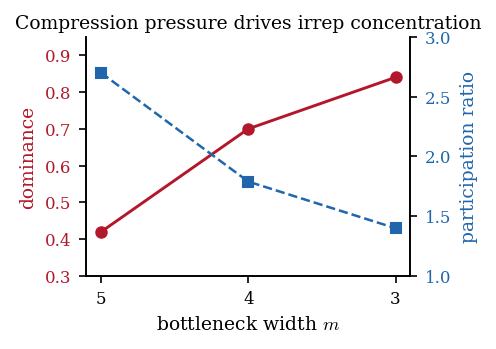

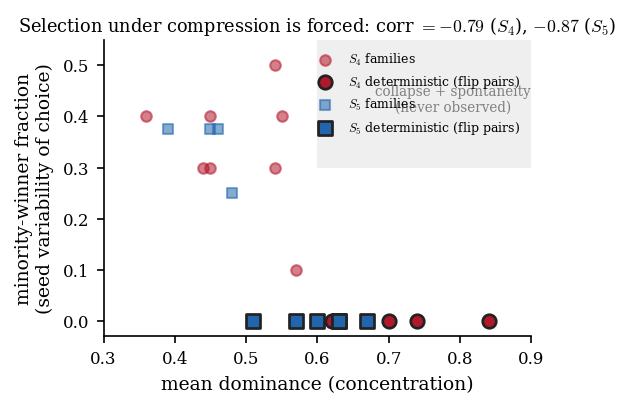

saved fig4_dose_response.{pdf,png}, fig5_dichotomy.{pdf,png}


In [ ]:
# =====================================================================================
# TMS FIGURES (Figures 4-5 of the paper). Real data from the S_4 and S_5 sweeps.
# Fig 4: dose-response — concentration vs bottleneck (S_4 Arm B + (0,1,8) full-scale).
# Fig 5: the dichotomy scatter — dominance vs minority-winner fraction, S_4 + S_5,
#        flip pairs highlighted. This is the TMS section's money figure.
# =====================================================================================
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm', 'font.size': 9, 'axes.linewidth': 0.8,
    'axes.labelsize': 9, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'legend.fontsize': 7.5, 'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'pdf.fonttype': 42,
})
C_S4, C_S5, C_FLIP = '#b2182b', '#2166ac', '#222222'

# ---------- DATA (from your runs; (dom, minority_fraction, label) per family x m row) ----------
# S_4 full-scale dichotomy table (10 seeds per row):
s4_rows = [  # (dominance, minority_frac, family, m, deterministic_flip_member)
    (0.70, 0.0, "(0,1,8)",          4, True),   # 10/10 b
    (0.84, 0.0, "(0,1,8)",          3, True),
    (0.45, 0.4, "(0,1,16)",         4, False),
    (0.36, 0.4, "(0,1,16)",         3, False),
    (0.45, 0.3, "(0,3,7)",          4, False),
    (0.44, 0.3, "(0,3,7)",          3, False),
    (0.54, 0.3, "(0,1,2,8,11)",     4, False),
    (0.57, 0.1, "(0,1,2,8,11)",     3, False),  # 9/1 a
    (0.54, 0.5, "(0,1,2,3,10,18)",  4, False),
    (0.55, 0.4, "(0,1,2,3,10,18)",  3, False),
    (0.62, 0.0, "(0,1,2,7,11)",     4, True),   # 10/10 a  <- flip partner of (0,1,8)
    (0.74, 0.0, "(0,1,2,7,11)",     3, True),
]
# S_5 deep-run table (8 seeds per row):
s5_rows = [
    (0.63, 0.0, "fam3", 5, True),   # 8/8 i
    (0.67, 0.0, "fam3", 4, True),
    (0.60, 0.0, "fam6", 5, True),   # 8/8 i
    (0.63, 0.0, "fam6", 4, True),
    (0.45, 3/8, "fam9", 5, False),
    (0.39, 3/8, "fam9", 4, False),
    (0.48, 2/8, "fam0", 5, False),
    (0.46, 3/8, "fam0", 4, False),
    (0.57, 0.0, "fam7", 5, True),   # 8/8 j  <- flip partner of fam3/6
    (0.51, 0.0, "fam7", 4, True),
]
# S_4 dose-response, family (0,1,8): (m, mean dominance over seeds)
dose_m   = [5, 4, 3]
dose_dom = [0.42, 0.70, 0.84]   # m=5 from the Cell-2 split rows (~0.42 avg), m=4/3 full-scale
dose_pr  = [2.7, 1.79, 1.40]

# ---------- FIGURE 4: dose-response ----------
fig, ax1 = plt.subplots(figsize=(3.4, 2.4))
ax1.plot(dose_m, dose_dom, 'o-', color=C_S4, lw=1.4, ms=5, label='dominant-irrep fraction')
ax1.set_xlabel('bottleneck width $m$'); ax1.set_ylabel('dominance', color=C_S4)
ax1.set_xticks(dose_m); ax1.invert_xaxis()              # pressure increases rightward
ax1.set_ylim(0.3, 0.95); ax1.tick_params(axis='y', labelcolor=C_S4)
ax2 = ax1.twinx()
ax2.plot(dose_m, dose_pr, 's--', color=C_S5, lw=1.2, ms=4.5, label='participation ratio')
ax2.set_ylabel('participation ratio', color=C_S5)
ax2.set_ylim(1.0, 3.0); ax2.tick_params(axis='y', labelcolor=C_S5)
for ax in (ax1, ax2): ax.spines[['top']].set_visible(False)
ax1.set_title('Compression pressure drives irrep concentration', fontsize=9, pad=4)
plt.tight_layout(); plt.savefig('fig4_dose_response.pdf'); plt.savefig('fig4_dose_response.png'); plt.show()

# ---------- FIGURE 5: the dichotomy scatter ----------
fig, ax = plt.subplots(figsize=(3.8, 2.8))
for rows, color, marker, label in [(s4_rows, C_S4, 'o', '$S_4$'), (s5_rows, C_S5, 's', '$S_5$')]:
    dom  = [r[0] for r in rows]; minf = [r[1] for r in rows]
    det  = [r[4] for r in rows]
    ax.scatter([d for d,k in zip(dom,det) if not k], [m for m,k in zip(minf,det) if not k],
               c=color, marker=marker, s=26, alpha=0.55, label=f'{label} families')
    ax.scatter([d for d,k in zip(dom,det) if k], [m for m,k in zip(minf,det) if k],
               facecolors=color, edgecolors=C_FLIP, linewidths=1.3, marker=marker, s=42,
               label=f'{label} deterministic (flip pairs)')
# the forbidden quadrant: collapse + spontaneity (never observed)
ax.add_patch(plt.Rectangle((0.6, 0.3), 0.4, 0.25, facecolor='grey', alpha=0.12, edgecolor='none'))
ax.text(0.79, 0.41, 'collapse + spontaneity\n(never observed)', fontsize=6.5,
        ha='center', color='grey')
ax.set_xlabel('mean dominance (concentration)')
ax.set_ylabel('minority-winner fraction\n(seed variability of choice)')
ax.set_xlim(0.3, 0.9); ax.set_ylim(-0.03, 0.55)
ax.spines[['top','right']].set_visible(False)
ax.legend(frameon=False, loc='upper right', fontsize=6)
ax.set_title(r'Selection under compression is forced: corr $=-0.79$ ($S_4$), $-0.87$ ($S_5$)',
             fontsize=8.5, pad=4)
plt.tight_layout(); plt.savefig('fig5_dichotomy.pdf'); plt.savefig('fig5_dichotomy.png'); plt.show()
print("saved fig4_dose_response.{pdf,png}, fig5_dichotomy.{pdf,png}")

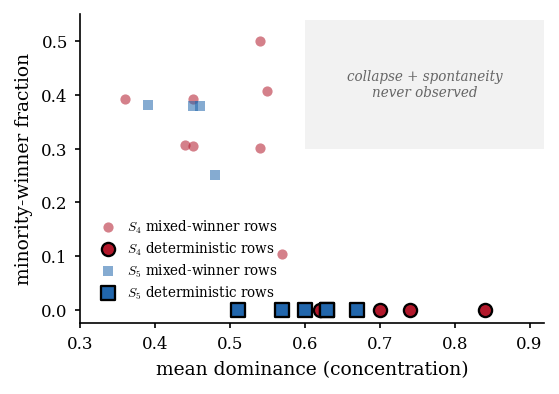

In [ ]:
# ---------- FIGURE 5 (tidied): the dichotomy scatter ----------
fig, ax = plt.subplots(figsize=(3.8, 2.7))

for rows, color, marker, label in [(s4_rows, C_S4, 'o', '$S_4$'), (s5_rows, C_S5, 's', '$S_5$')]:
    dom  = np.array([r[0] for r in rows]); minf = np.array([r[1] for r in rows])
    det  = np.array([r[4] for r in rows])
    # tiny vertical jitter on NON-deterministic points only, so stacked values are visible
    rng_j = np.random.default_rng(0)
    jit = rng_j.uniform(-0.008, 0.008, size=len(rows))
    ax.scatter(dom[~det], minf[~det] + jit[~det], c=color, marker=marker, s=24,
               alpha=0.55, linewidths=0, label=f'{label} mixed-winner rows')
    ax.scatter(dom[det], minf[det], facecolors=color, edgecolors='black',
               linewidths=1.1, marker=marker, s=40, label=f'{label} deterministic rows')

# forbidden quadrant: annotation INSIDE the patch, legend kept away from it
ax.add_patch(plt.Rectangle((0.6, 0.3), 0.32, 0.24, facecolor='grey', alpha=0.10, edgecolor='none'))
ax.text(0.76, 0.42, 'collapse + spontaneity\nnever observed', fontsize=6.5,
        ha='center', va='center', color='#666666', style='italic')

ax.set_xlabel('mean dominance (concentration)')
ax.set_ylabel('minority-winner fraction')
ax.set_xlim(0.3, 0.92); ax.set_ylim(-0.025, 0.55)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(length=2.5)
ax.legend(frameon=False, loc='lower left', bbox_to_anchor=(0.01, 0.04),
          fontsize=6.5, handletextpad=0.4, borderpad=0.2, labelspacing=0.35)
# no title — the caption does that job in the paper
plt.tight_layout()
plt.savefig('fig5_dichotomy.pdf'); plt.savefig('fig5_dichotomy.png'); plt.show()